# Trabajo Práctico 1 - Ciencia de Datos (2026) - Mantenimiento Predictivo Industrial

## Parte 1: Análisis Exploratorio de Datos (EDA)
En esta parte, se realiza el análisis exploratorio de los datos para comprender su estructura, identificar patrones, detectar valores atípicos y evaluar la calidad de los datos. Para esto, se realizan diversos cálculos cuyos resultados se presentan principalmente en formato de tablas y gráficos.

### Importación de librerías

In [17]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

### Carga del conjunto de datos

In [18]:
df = pd.read_csv('i40 (datos).csv')
print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado: 14521 filas x 9 columnas


,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


**Observaciones**: 
- El dataset contiene 14521 filas y 9 columnas.
- Probablemente tanto la columna idx como parent_device_id no aporten información relevante para el análisis, por lo que podrían ser descartados para simplificar el trabajo.
- Además de la columna de la etiqueta (target), la única columna categórica relevante es product_type.

### Visualizar información general del dataset

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14521 entries, 0 to 14520
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idx               14521 non-null  int64  
 1   parent_device_id  14521 non-null  int64  
 2   product_type      14521 non-null  str    
 3   air_temp [K]      14481 non-null  float64
 4   process_temp [K]  14521 non-null  float64
 5   speed [RPM]       14521 non-null  int64  
 6   torque [Nm]       14521 non-null  float64
 7   tool_wear [min]   14521 non-null  int64  
 8   target            14521 non-null  str    
dtypes: float64(3), int64(4), str(2)
memory usage: 1021.1 KB


**Observaciones**: 
- La columna air_temp [K] tiene solo 14481 valores no nulos, lo que indica que hay 40 filas con valores faltantes en esta columna.

### Medidas de Tendencia Central y Distribución de las Variables

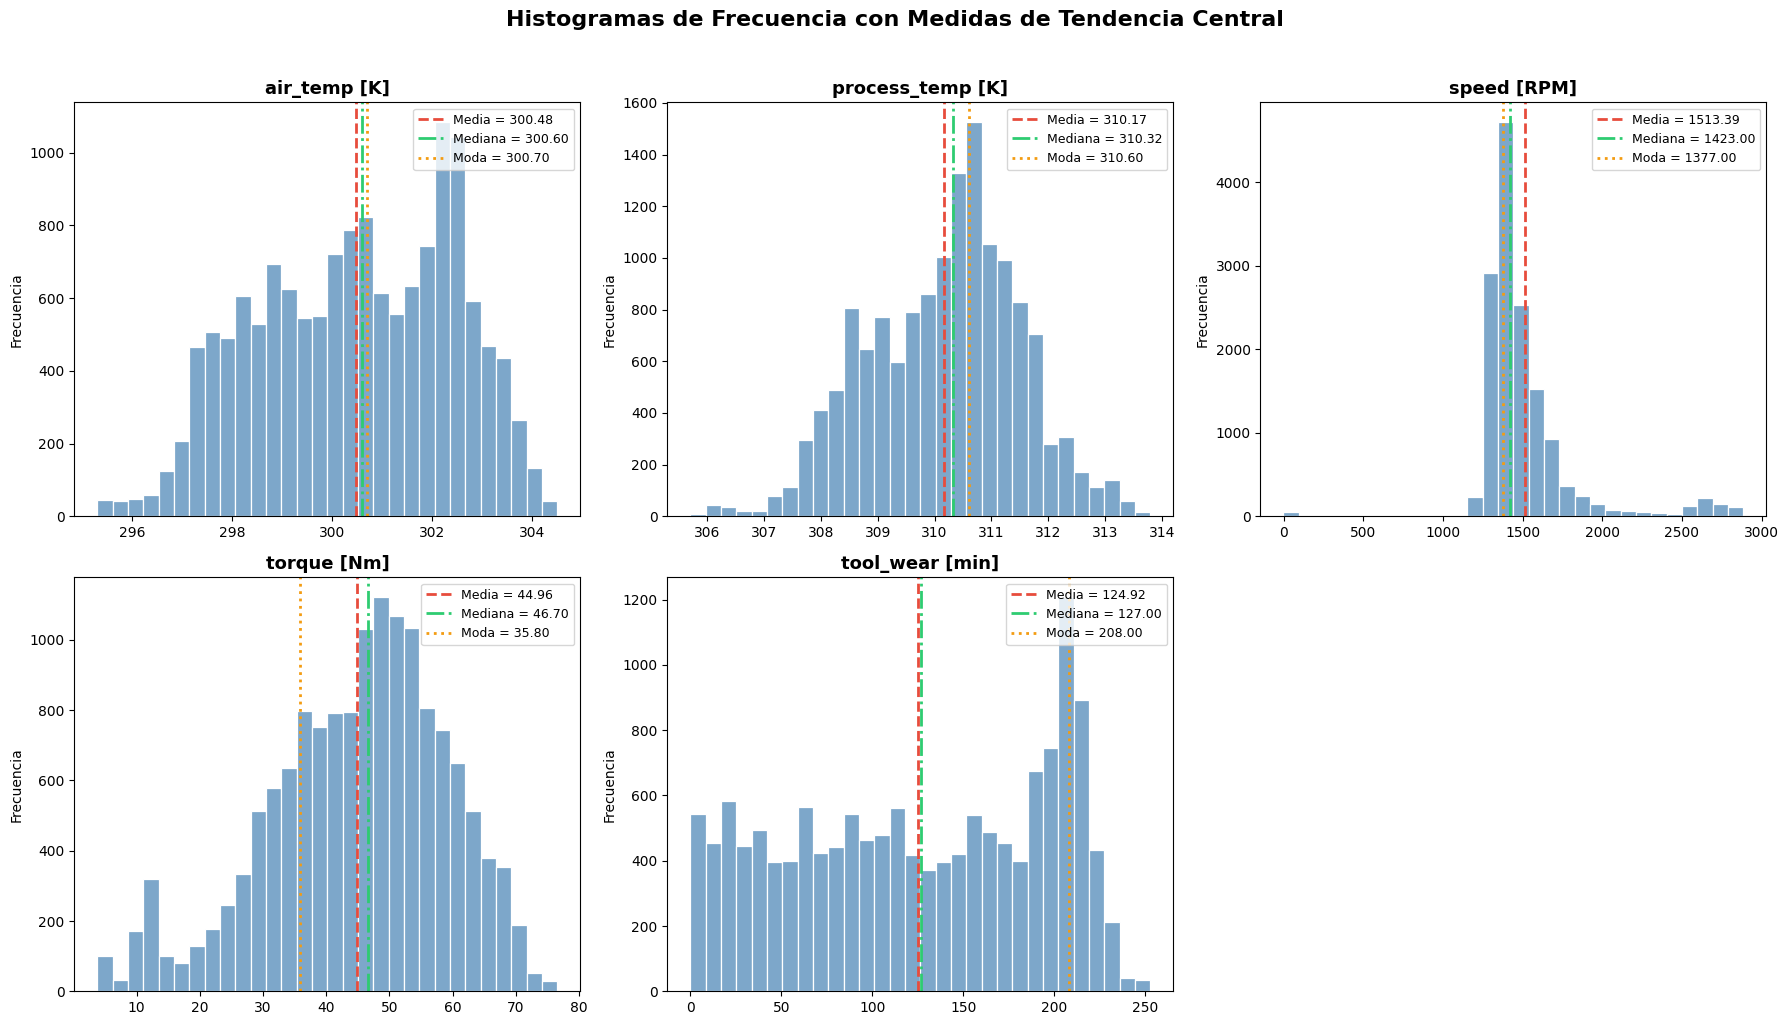

In [20]:
# Seleccionar únicamente las columnas numéricas relevantes (excluimos idx y parent_device_id)
columnas_numericas = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]

    # Histograma (frecuencia absoluta)
    sns.histplot(df[col], bins=30, kde=False, color='steelblue', edgecolor='white',
                 alpha=0.7, ax=ax, stat='count')

    # Cálculo de medidas de tendencia central
    media   = df[col].mean()
    mediana = df[col].median()
    moda    = df[col].mode()[0]

    # Líneas verticales para cada medida
    ax.axvline(media,   color='#e74c3c', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
    ax.axvline(mediana, color='#2ecc71', linestyle='-.',  linewidth=2, label=f'Mediana = {mediana:.2f}')
    ax.axvline(moda,    color='#f39c12', linestyle=':',   linewidth=2, label=f'Moda = {moda:.2f}')

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9, loc='upper right')

# Ocultar el subplot vacío (tenemos 5 gráficos en una grilla de 2x3)
axes[-1].set_visible(False)

fig.suptitle('Histogramas de Frecuencia con Medidas de Tendencia Central', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- Las columnas air_temp [K], process_temp [K] y torque [Nm] presentan distribuciones que parecen ser aproximadamente normales.
- Por otro lado, las columnas speed [RPM] y tool_wear [min] parecieran seguir alguna otra distribución.

### Medidas de Dispersión

In [21]:
resumen = pd.DataFrame({
    'Variable':   columnas_numericas,
    'Mínimo':     [df[c].min()                              for c in columnas_numericas],
    'Máximo':     [df[c].max()                              for c in columnas_numericas],
    'Rango':      [df[c].max() - df[c].min()                for c in columnas_numericas],
    'Q1':         [df[c].quantile(0.25)                     for c in columnas_numericas],
    'Q3':         [df[c].quantile(0.75)                     for c in columnas_numericas],
    'IQR':        [df[c].quantile(0.75) - df[c].quantile(0.25) for c in columnas_numericas],
    'Varianza':   [df[c].var()                              for c in columnas_numericas],
    'Desv. Est.': [df[c].std()                              for c in columnas_numericas],
    'CV (%)':     [df[c].std() / df[c].mean() * 100         for c in columnas_numericas]
}).set_index('Variable')

# Mostrar la tabla con 2 decimales
resumen.round(2)

,Mínimo,Máximo,Rango,Q1,Q3,IQR,Varianza,Desv. Est.,CV (%)
Variable,,,,,,,,,
air_temp [K],295.3,304.5,9.2,298.90,302.20,3.30,3.81,1.95,0.65
process_temp [K],305.7,313.8,8.1,309.20,311.09,1.89,1.77,1.33,0.43
speed [RPM],-1.0,2886.0,2887.0,1354.00,1561.00,207.00,98347.58,313.60,20.72
torque [Nm],3.8,76.6,72.8,35.99,55.00,19.01,202.40,14.23,31.65
tool_wear [min],0.0,253.0,253.0,64.00,193.00,129.00,4914.85,70.11,56.12


### Proporciones de las Columnas Categóricas

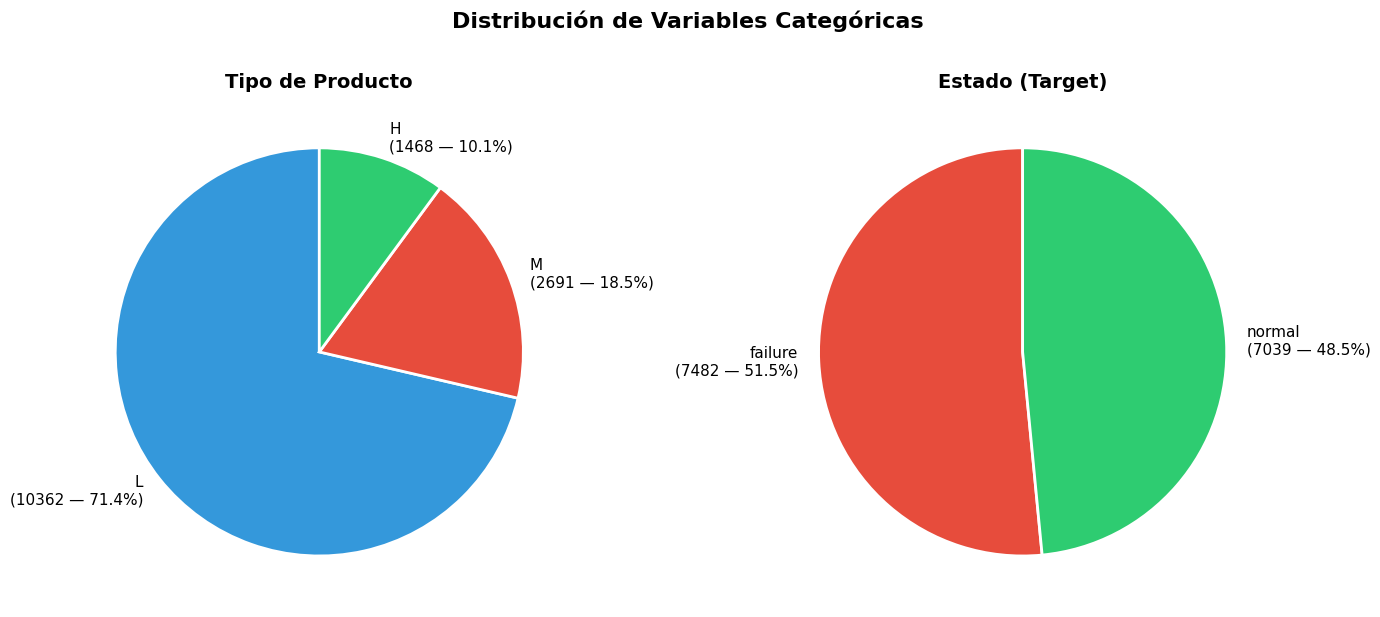

In [22]:
columnas_categoricas = ['product_type', 'target']
titulos = ['Tipo de Producto', 'Estado (Target)']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Paletas de colores
paletas = [
    ['#3498db', '#e74c3c', '#2ecc71'],   # product_type: L, M, H
    ['#e74c3c', '#2ecc71']               # target: failure, normal
]

for i, col in enumerate(columnas_categoricas):
    ax = axes[i]
    conteos = df[col].value_counts()
    proporciones = conteos / conteos.sum() * 100

    # Etiquetas con conteo y porcentaje
    etiquetas = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos.index, conteos.values, proporciones.values)]

    wedges, texts = ax.pie(
        conteos.values,
        labels=etiquetas,
        colors=paletas[i],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    # Ajustar tamaño de fuente de etiquetas
    for t in texts:
        t.set_fontsize(11)

    ax.set_title(titulos[i], fontsize=14, fontweight='bold')

fig.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- Con la proporción de la columna target (Estado), se puede observar que el dataset está ligeramente desbalanceado. Sabiendo esto, se podrían aplicar técnicas de balanceo de clases en etapas posteriores del análisis para mejorar el rendimiento de los modelos predictivos. Sin embargo, también hay que considerar la posibilidad de no balancear en absoluto, dado que:
    - La diferencia de proporción es mínima.
    - Y en teoría, cuando hay desbalanceo de clases, los modelos tienen a dar mejores resultados en la clase mayoritaria, lo que podría ser beneficioso en este caso, ya que el objetivo es predecir si hay una falla en las máquinas, y bajo este escenario puede ser preferible tener un falso positivo de falla antes que clasificar una falla como normal.

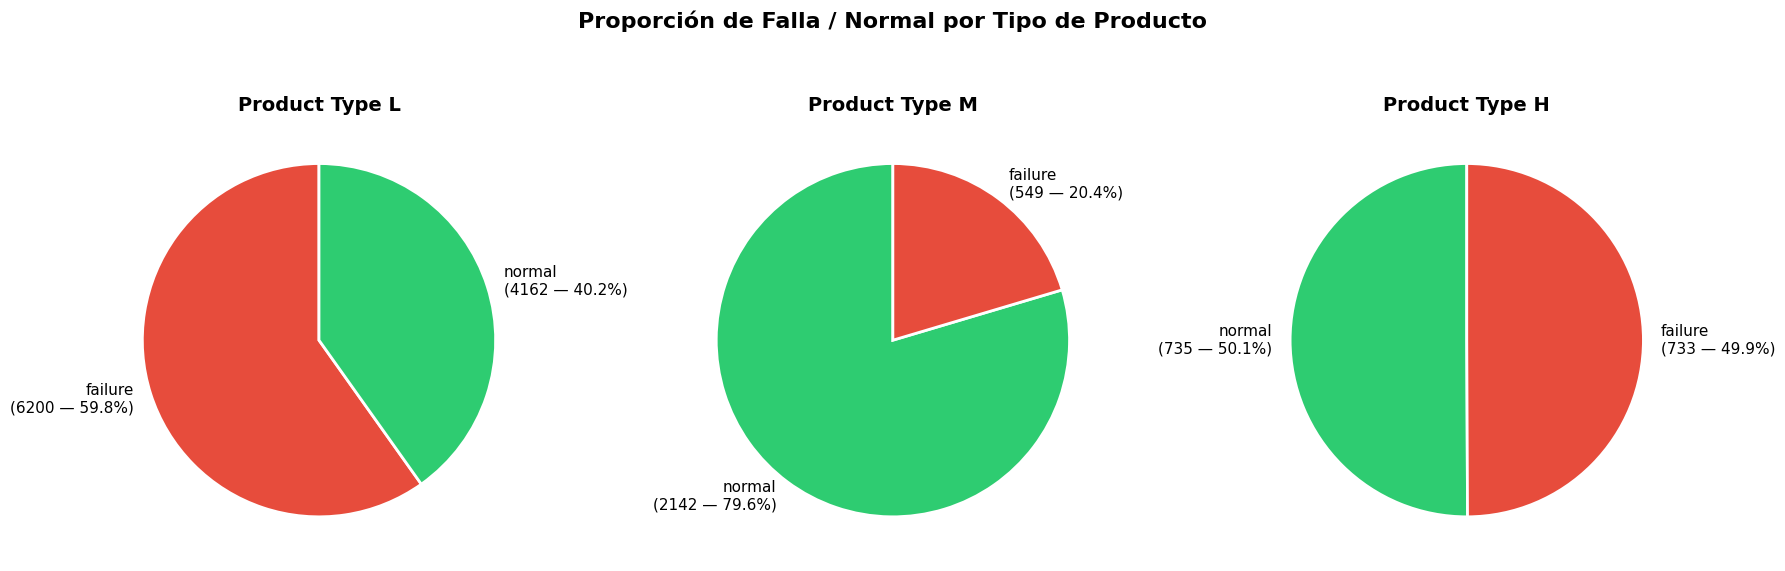

In [23]:
tipos_producto = ['L', 'M', 'H']
color_map = {'failure': '#e74c3c', 'normal': '#2ecc71'}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, prod in enumerate(tipos_producto):
    ax = axes[i]
    conteos = df.loc[df['product_type'] == prod, 'target'].value_counts()
    proporciones = conteos / conteos.sum() * 100

    etiquetas = [f'{val}\n({cnt} — {prop:.1f}%)' for val, cnt, prop
                 in zip(conteos.index, conteos.values, proporciones.values)]
    
    # Asignar los colores haciendo un mapeo estático con el índice (categoría) para asegurar consistencia
    colores_pie = [color_map[idx] for idx in conteos.index]

    wedges, texts = ax.pie(
        conteos.values,
        labels=etiquetas,
        colors=colores_pie,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    for t in texts:
        t.set_fontsize(11)

    ax.set_title(f'Product Type {prod}', fontsize=14, fontweight='bold')

fig.suptitle('Proporción de Falla / Normal por Tipo de Producto', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- La proporciones para product_type "L" y "H" no representan diferencias significativas. Por otro lado, la proporción para product_type "M" indica que solo el 20% de los productos del tipo M tienen una falla, lo que podría sugerir que el tipo de producto M es menos propenso a fallas en comparación con los tipos L y H, tal vez por características específicas de ese tipo de producto o por condiciones de operación particulares. Esto podría ser un punto de interés para investigar más a fondo en etapas posteriores del análisis.

### Diagramas de Caja (Box Plots)

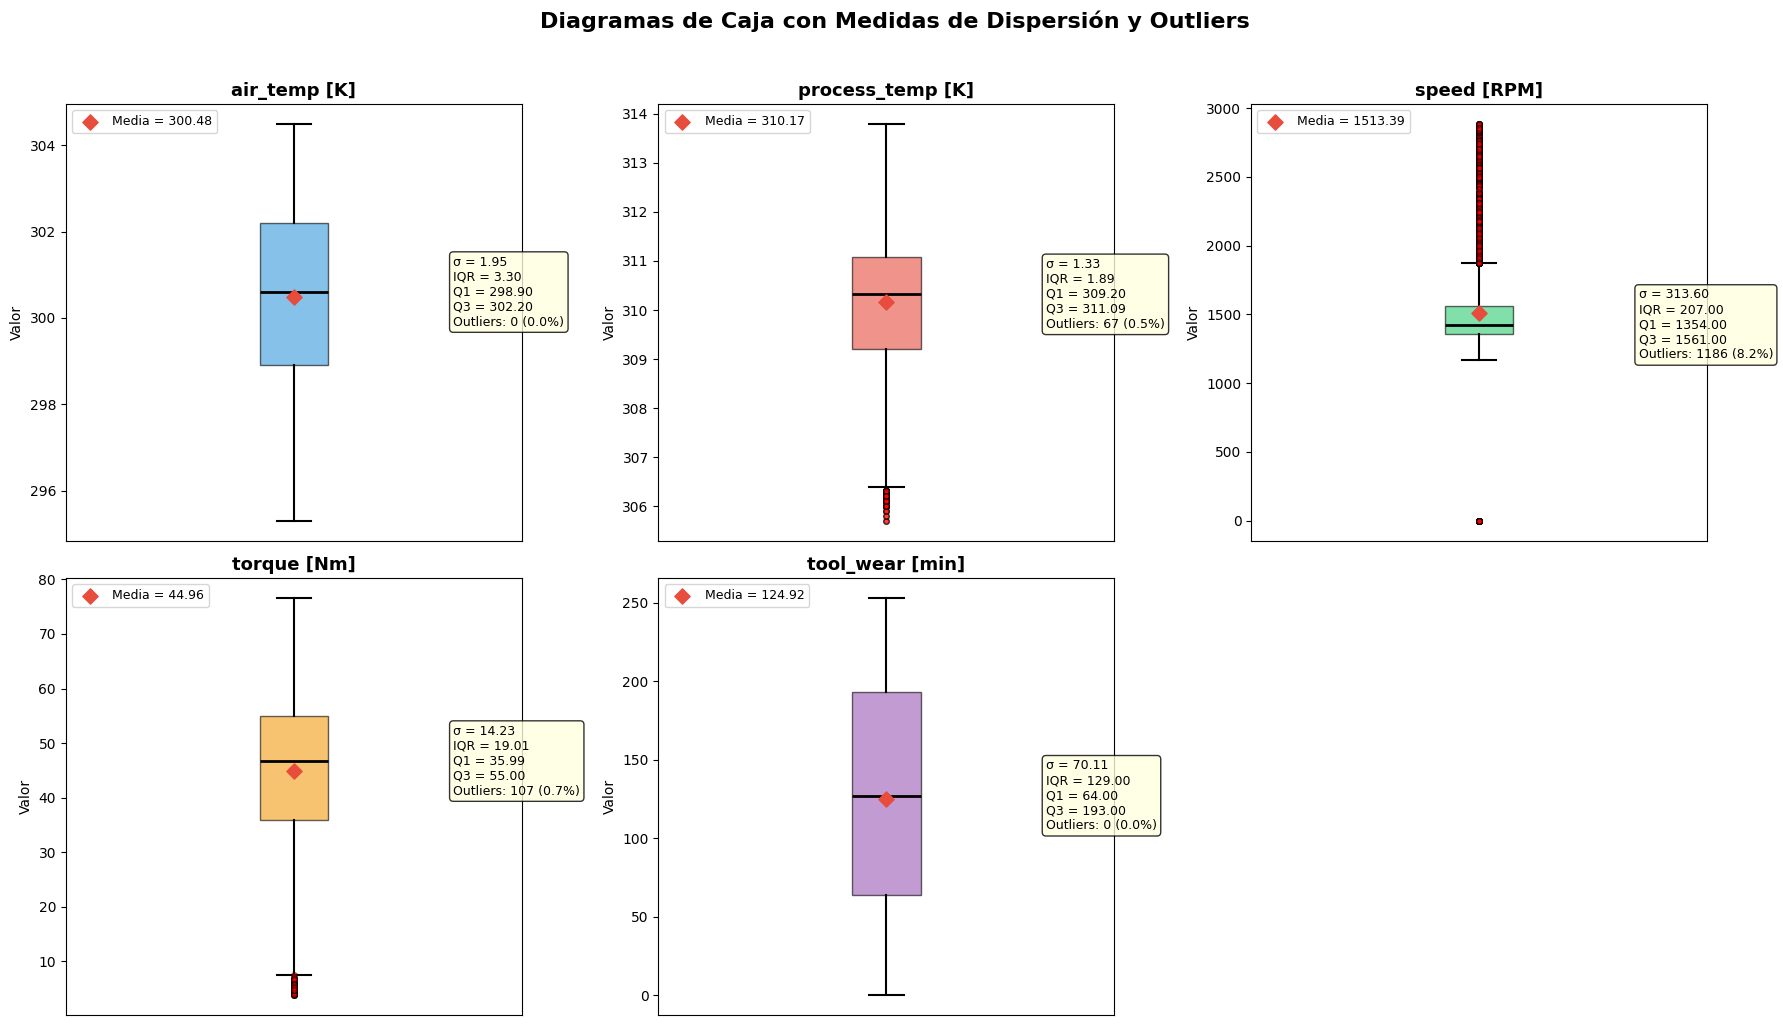

In [24]:
# --- Box Plots para cada variable numérica (con conteo de outliers) ---

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

colores_box = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, col in enumerate(columnas_numericas):
    df_sin_nulos = df[col].dropna()
    
    ax = axes[i]

    bp = ax.boxplot(df_sin_nulos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colores_box[i], alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))

    # Estadísticas
    media   = df_sin_nulos.mean()
    std     = df_sin_nulos.std()
    mediana = df_sin_nulos.median()
    q1      = df_sin_nulos.quantile(0.25)
    q3      = df_sin_nulos.quantile(0.75)
    iqr     = q3 - q1

    # Contar outliers (método IQR: valores fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR])
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    n_out   = ((df_sin_nulos < lim_inf) | (df_sin_nulos > lim_sup)).sum()
    pct_out = n_out / len(df_sin_nulos) * 100

    # Marcar la media con un diamante
    ax.scatter([1], [media], marker='D', color='#e74c3c', s=60, zorder=5, label=f'Media = {media:.2f}')

    # Texto con estadísticas de dispersión + outliers
    stats_text = (f'σ = {std:.2f}\n'
                  f'IQR = {iqr:.2f}\n'
                  f'Q1 = {q1:.2f}\n'
                  f'Q3 = {q3:.2f}\n'
                  f'Outliers: {n_out} ({pct_out:.1f}%)')
    ax.text(1.35, mediana, stats_text, fontsize=9, va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_xticks([])
    ax.legend(fontsize=9, loc='upper left')

# Ocultar el subplot vacío
axes[-1].set_visible(False)

fig.suptitle('Diagramas de Caja con Medidas de Dispersión y Outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Análisis de Correlación

#### Correlación de Pearson

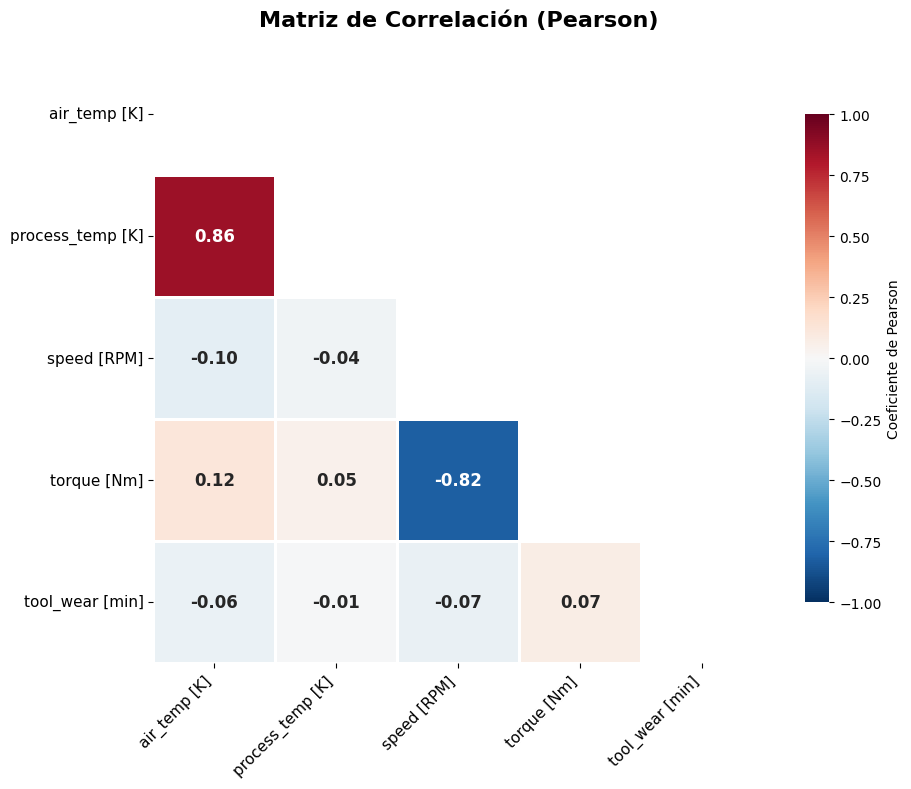

In [25]:
# --- Heatmap de la matriz de correlación (Pearson) ---

# Calcular la matriz de correlación solo para las columnas numéricas relevantes
corr_matrix = df[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Crear máscara para el triángulo superior (evitar redundancia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=1, linecolor='white',
            square=True, ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Coeficiente de Pearson', 'shrink': 0.8})

ax.set_title('Matriz de Correlación (Pearson)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

#### Gráfico de Dispersión para Analizar Correlación entre Variables

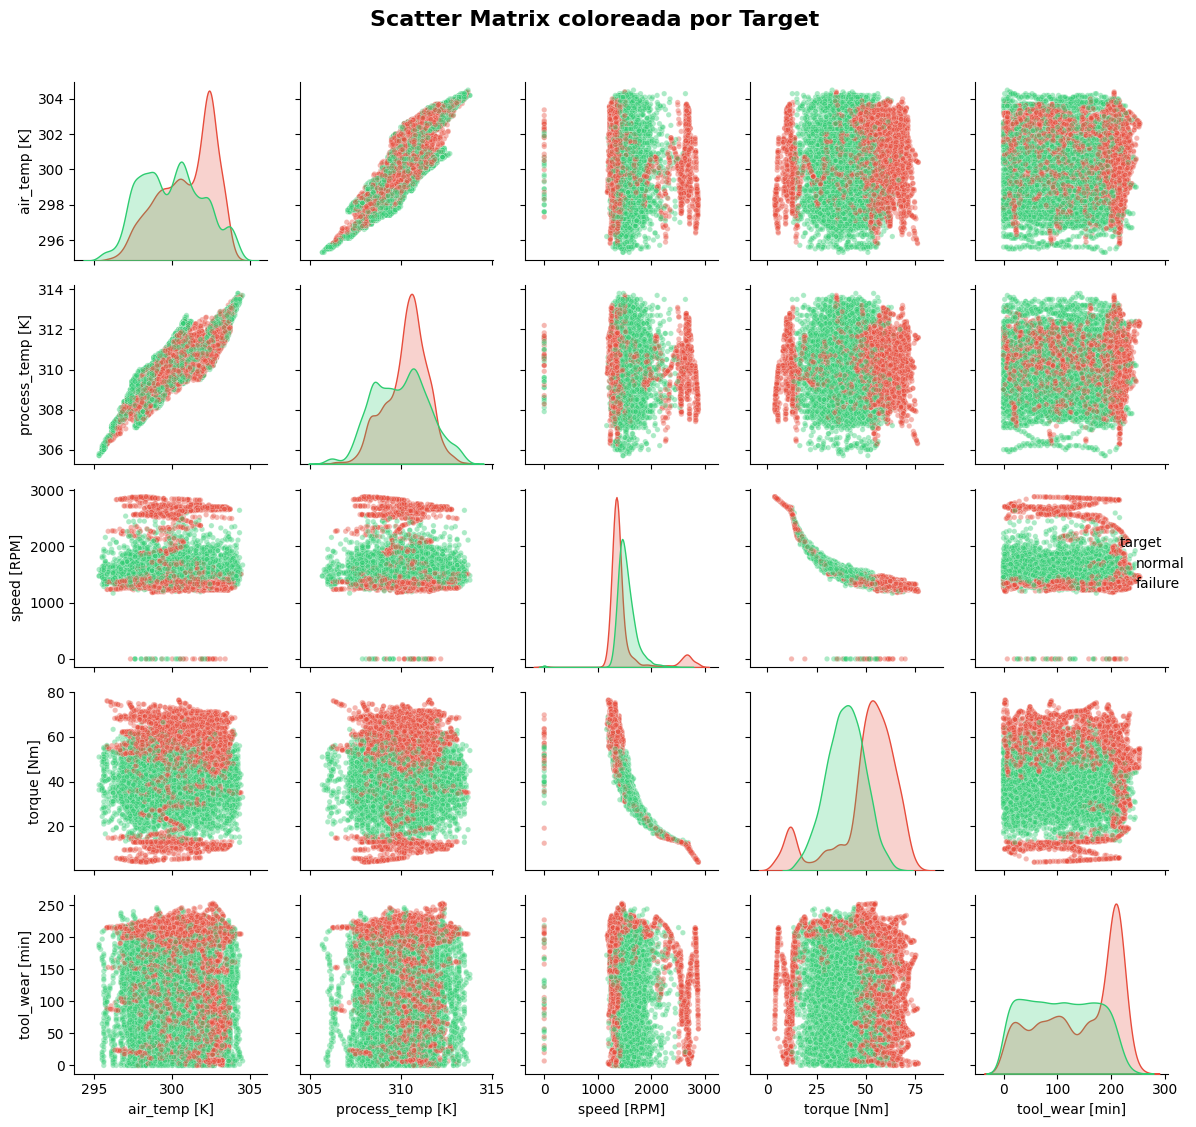

In [26]:
# --- Pairplot (scatter matrix) coloreado por la variable target ---

g = sns.pairplot(df[columnas_numericas + ['target']], hue='target',
                 palette={'failure': '#e74c3c', 'normal': '#2ecc71'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 height=2.2)

g.figure.suptitle('Scatter Matrix coloreada por Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones**:
- En este gráfico se puede observar que la relación entre speed [RPM] y torque [Nm] es bastante fuerte, lo que se refleja en el valor de la correlación de Pearson (-0.82) calculado anteriormente. Sin embargo, también se puede observar que dicha relación es no lineal, por lo que es importante también considerar la correlación de Spearman.
- Para el caso de air_temp [K] y process_temp [K], se puede observar que la relación entre ambas variables también es bastante fuerte, como sugiere el valor de la correlación de Pearson calculada anteriormente (0.86). En este caso, la relación sí pareciera ser lineal.

#### Correlación de Spearman

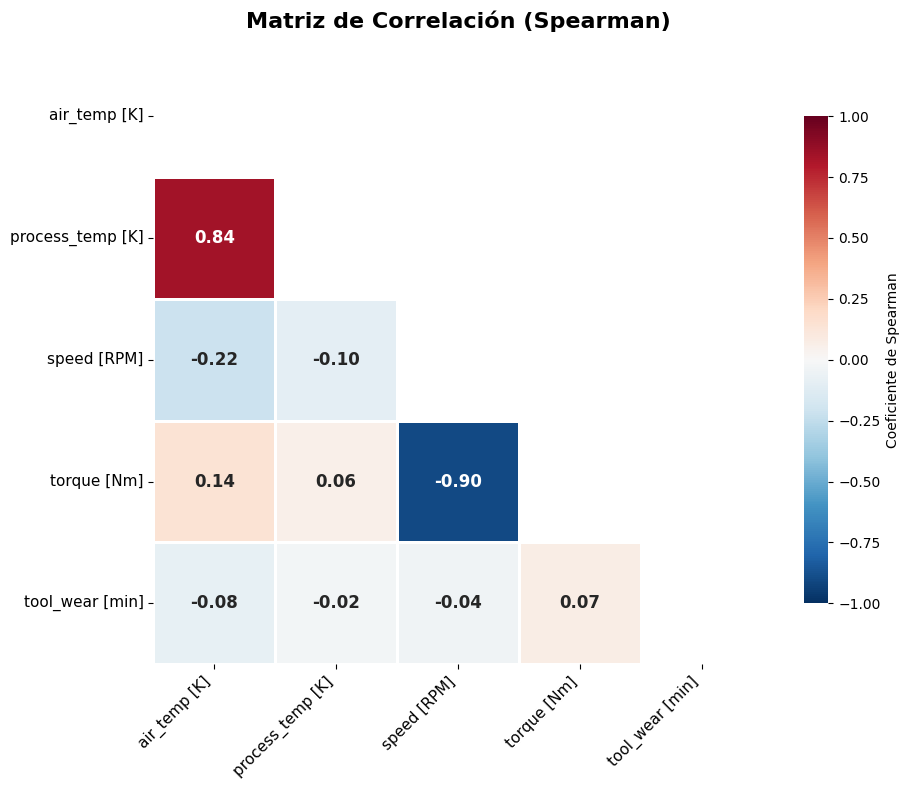

In [27]:
# --- Heatmap de la matriz de correlación (Spearman) ---
corr_spearman = df[columnas_numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=1, linecolor='white',
            square=True, ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Coeficiente de Spearman', 'shrink': 0.8})

ax.set_title('Matriz de Correlación (Spearman)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

**Observaciones**:
- Con este resultado, podemos ver que la correlación de Spearman entre speed [RPM] y torque [Nm] es aún más fuerte que la correlación de Pearson, lo que sugiere que la relación entre estas dos variables es monotónica, aunque no necesariamente lineal. Esto refuerza la idea de que la relación entre speed y torque es fuerte, pero no lineal.

## Parte 2.1: Preprocesamiento de los Datos

### Eliminar Columnas Irrelevantes

In [28]:
df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


In [29]:
# Contabilizar la cantidad de valores únicos en 'idx' y 'parent_device_id'
valores_unicos = df[['idx', 'parent_device_id']].nunique()
print("Cantidad de valores únicos por columna:")
print(valores_unicos)
print("Cantidad de filas en el DataFrame:", df.shape[0])

Cantidad de valores únicos por columna:
idx                 14521
parent_device_id    14521
dtype: int64
Cantidad de filas en el DataFrame: 14521


**Observación**: Contabilizando la cantidad de valores únicos en estas columnas podemos confirmar que se tratan de valores de identificación únicos por cada fila (más allá de que el nombre ya lo sugería). Sabiendo esto, nos conviene eliminar estas columnas para simplificar el trabajo.

In [30]:
# Eliminamos las columnas 'idx' y 'parent_device_id'
df = df.drop(columns=['idx', 'parent_device_id'])

### Codificación de Columnas Categóricas

In [31]:
# Mapeo manual para respetar el orden jerárquico (L < M < H)
mapeo_producto = {'L': 0, 'M': 1, 'H': 2}

# Aplicar la codificación a la columna product_type
df['product_type'] = df['product_type'].map(mapeo_producto)

# Verificar el resultado
print("\nPrimeras filas del DataFrame con product_type codificado:")
df.head()


Primeras filas del DataFrame con product_type codificado:


,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,303.80,313.30,1406,52.10,166,normal
1,0,302.30,311.20,1633,36.40,114,normal
2,1,302.27,311.47,1228,68.75,187,failure
3,0,302.35,311.93,1522,36.99,214,failure
4,0,296.70,307.90,1743,27.90,55,normal


### Imputación de Valores Faltantes

In [15]:
# Verificar si existen valores faltantes
df.isnull().sum()

product_type         0
air_temp [K]        40
process_temp [K]     0
speed [RPM]          0
torque [Nm]          0
tool_wear [min]      0
target               0
dtype: int64

**Observación**: Solo hay 40 filas con valores faltantes en la columna air_temp [K].

In [16]:
# Observamos las filas con la columna air_temp [K] faltante
df[pd.isnull(df['air_temp [K]'])]

,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
1448,L,NaN,312.40,1404,61.50,127,failure
1449,L,NaN,311.51,1371,47.22,60,failure
1450,L,NaN,309.51,1337,63.61,206,failure
3901,L,NaN,309.82,1981,20.50,203,failure
3902,L,NaN,311.00,1428,47.90,174,normal
3903,M,NaN,312.34,2687,10.48,67,failure
3904,L,NaN,311.50,1663,33.60,38,normal
3905,L,NaN,308.00,1423,38.00,154,normal
3906,M,NaN,311.10,1647,31.60,6,normal
3907,M,NaN,308.80,1683,31.60,79,normal


In [95]:
# Observamos las filas que sí tienen la columna air_temp [K]
df[pd.notnull(df['air_temp [K]'])]

,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,L,303.80,313.30,1406,52.10,166,normal
1,L,302.30,311.20,1633,36.40,114,normal
2,M,302.27,311.47,1228,68.75,187,failure
3,L,302.35,311.93,1522,36.99,214,failure
4,L,296.70,307.90,1743,27.90,55,normal
...,...,...,...,...,...,...,...
14516,H,296.79,307.90,1385,62.32,99,failure
14517,L,302.90,311.21,1336,52.93,163,failure
14518,M,302.53,311.91,2701,9.95,68,failure
14519,L,300.11,309.98,1466,58.86,164,failure


In [32]:
from sklearn.impute import KNNImputer

# Inicializamos el imputador KNN con 5 vecinos por defecto
imputer = KNNImputer(n_neighbors=5)

# Seleccionamos las variables numéricas que nos ayudarán a imputar razonablemente
columnas_imputacion = ['product_type', 'air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

# Aplicamos la imputación de KNN y actualizamos la/las columnas en el dataset
df[columnas_imputacion] = imputer.fit_transform(df[columnas_imputacion])

**Observación**: Aunque sabemos debido a las dimensiones del dataset es conveniente usar técnicas de imputación simples (como imputación mediante media o mediana), con fines educativos hemos decido aplicar el módulo *KNNImputer* de la biblioteca sklearn, como técnica de impuación para la columna air_temp [K]. 

In [33]:
# Verificar que no queden valores faltantes
df.isnull().sum()

product_type        0
air_temp [K]        0
process_temp [K]    0
speed [RPM]         0
torque [Nm]         0
tool_wear [min]     0
target              0
dtype: int64

### Imputación de Valores Atípicos

In [ ]:
## Boxplot para visualizar valores atípicos
# TODO: USAR MISMO BOXPLOT QUE EL DE ARRIBA 

In [ ]:
## Optamos por reemplazar los valores por la mediana de los valores correctos
df.loc[df.IMC == 0, 'IMC'] = df.IMC.median()

In [ ]:

# TODO: VISUALIZAR BOXPLOT DE NUEVO PARA VERIFICAR CAMBIOS (opcional)

Para optimizar el conjunto de datos y mejorar la robustez de los modelos de predicción de mantenimiento, se procedió a la eliminación de la columna speed [RPM] basándose en los siguientes criterios técnicos:
- Multicolinealidad y Redundancia: Se detectó una correlación negativa muy fuerte (aprox -0.90) entre torque [Nm] y speed [RPM]. Esta relación responde a la naturaleza física de los motores bajo carga, donde ambas variables actúan como dos caras de la misma moneda informativa.Mantener ambas variables introduciría redundancia, lo cual puede afectar negativamente la interpretabilidad y la convergencia de ciertos algoritmos de aprendizaje automático.
- Speed esta más correlacionada con las demás que torque, por lo que también es mejor eliminar speed antes que torque.
- Integridad de los Datos: La columna speed presentaba una serie de valores anómalos (marcados como -1) que representaban datos faltantes o fallas en la sensórica. Dado que el torque se encuentra completo y captura la misma dinámica operativa, su uso como variable representativa es más fiable que intentar una imputación (lineal o no lineal) en speed, evitando así la introducción de ruido o sesgos artificiales en el dataset.
- Simplificación del Modelo (Navaja de Ockham): Al eliminar la variable redundante, se reduce la dimensionalidad del problema sin perder poder explicativo. Esto favorece la creación de un modelo más simple, computacionalmente más eficiente y con menor riesgo de overfitting (sobreajuste).

### Selección de Características 

In [29]:

# TODO: CALCULAR los promedios de las columnas en la matriz de correlación de Spearman
# Dados los coeficientes de spearman obtenidos entre torque y speed, 
# cuyo valor absoluto es >= 0.9, podemos eliminar la del mayor promedio de correlación (la más redundante).

# Calculamos la matriz de correlación absoluta
corr = df.corr(numeric_only=True, method='spearman').abs()
corr

,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min]
air_temp [K],1.000000,0.837512,0.215909,0.142401,0.078606
process_temp [K],0.837512,1.000000,0.098154,0.060971,0.023701
speed [RPM],0.215909,0.098154,1.000000,0.902622,0.040175
torque [Nm],0.142401,0.060971,0.902622,1.000000,0.073950
tool_wear [min],0.078606,0.023701,0.040175,0.073950,1.000000


In [31]:
# Calculamos un vector con las medias de cada columna
column_mean = corr.mean(axis=1)
column_mean

air_temp [K]        0.454886
process_temp [K]    0.404068
speed [RPM]         0.451372
torque [Nm]         0.435989
tool_wear [min]     0.243286
dtype: float64

In [ ]:
# Eliminamos la columna con mayor promedio de correlación (entre torque y speed)
#eliminamos speed:
df = df.drop(columns=['speed'])

Columna a eliminar por alta correlación: air_temp [K]


# TAREAS
Agregar tareasa que falten o marcar como hechas en caso de hacerlas.


## Análisis Exploratorio
- [x] Verificar si hay valores nulos.
- [x] Verificar si hay valores atípicos.
- [x] Verificar balance de clases.
- [x] Graficar histogramas superpuestos: histograma con categoría positiva e histograma con categoría negativa. Estos gráficos están en en la diagonal de la matriz de gáficos de dispersión, por lo que se pueden observar a partir de ahí.
- [x] Parecen haber correlaciones no lineales entre algunas variables, calcular tanto correlacion de Pearson y Spearman.

## Preprocesamiento de los Datos
- [x] Analizar si hay que eliminar columnas irrelevantes. *(se eliminaron los idx y parent_device_id).*
- [x] Analizar si hay que realizar imputación para los datos erróneos (inválidos o atípicos) o faltantes o si es mejor eliminar las correspondientes filas. *(se decidió realizar imputación para los datos faltantes y atípicos utilizando KNNImputer).*
- [ ] Analizar si conviene realizar normalizacion o estandarización para las variables numéricas.
- [x] Analizar si hay que realizar encoding de variables categóricas y qué tipo de encoding conviene utilizar. *(se decidió usar LabelEncoder).*
- [x] Analizar si hay que realizar oversampling o undersampling para balancear las clases. Tener en cuenta observación de la parte 1. *(se decidió mantener el desbalanceo de clases pero prestar atención al recall).*
- [ ] Analizar si conviene eliminar alguna columna de acuerdo a las altas correlaciones y el promedio de correlaciones en caso de haber varias columnas con alta correlación.
- [ ] Guardar el dataset preprocesado para usarlo en la etapa de entrenamiento en un archivo nuevo CSV (preprocessed_data.csv).

## Entrenamiento
- [ ] Elegir un modelo de clasificación adecuado para el problema y justificar la elección.
- [ ] Realizar ajuste de hiperparámetros para el modelo elegido.
- [ ] Graficar y analizar matriz de confusión.
- [ ] Calcular y analizar métricas de evaluación (accuracy, precisión, recall, F1-score).



# Preguntas
1. Con respecto al preprocesado del conjunto de datos (parte 2.1): En el enunciado, la parte 1 es principalmente realizar el análisis exploratorio (analizar patrones y entender los datos) y la parte 2.1 es el preprocesamiento de los datos (limpieza, imputación, escalado, codificación, etc). Sin embargo, creo que la parte de limpieza e imputación debería ir **antes** del análisis exploratorio, ya que de otra forma cualquier gráfico o estadística estaría mostrando una realidad distorsionada. Luego, una vez que los datos estén limpios, se deberían volver a generar los gráficos y estadísticas para obtener una visión más precisa de la realidad representada por los datos. Finalmente, luego del análisis exploratorio sí iría la parte de escalado, codificación y balanceo de clases en caso de ser necesario. ¿Qué opinan al respecto? Habría que preguntarle al profe, ya que puede que realizar análisis exploratorio con datos imputados no sea lo ideal.


==PREGUNTA==:
- Quisimos realizar KNNImputer para imputación de valores faltantes, pero no sabemos si incluir o no la columna product_type (categórica) para la interpolación y si deberíamos o no aplicar alguna técnica de codificación previa (como One-Hot Encoding) para esta columna antes de aplicar KNNImputer. ¿Qué nos recomiendan hacer en este caso?

- ¿Qué representa la columna product_type? ¿Qué es?